In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.integrate import *
import torch
from bh_horizons import *

In [3]:
def P(V, k):
    """Polynomial that vanishes up to k-th derivative at V=0 and V=1."""
    return V**(k+1) * (1 - V)**(k+1)

def dP(V, k):
    """Derivative of the polynomial P(V, k)."""
    return (k+1) * V**k * (1 - V)**(k+1) - (k+1) * V**(k+1) * (1 - V)**k

In [139]:
def unpack_theta(theta):
    """Unpack the neural network parameters from theta."""
    p = (len(theta) - 1) // 3
    a0 = theta[0]
    a = theta[1:p+1]
    w = theta[p+1:2*p+1]
    b = theta[2*p+1:]
    return a0, a, w, b

In [140]:
def rho_drho(V, theta, k):
    """Neural network Ansatz for rho and its derivative."""
    a0, a, w, b = unpack_theta(theta)
    
    # Neural network part
    V = np.asarray(V, dtype=float)
    z = V[..., None] * w + b
    NN = a0 + np.sum(a * np.tanh(z), axis=-1)
    dNN = np.sum(a * w * (1 - np.tanh(z)**2), axis=-1)
    
    # Polynomial part
    Pk, dPk = P(V, k), dP(V, k)
    
    rho = Pk * NN
    drho_dV = dPk * NN + Pk * dNN
    
    return rho, drho_dV

In [ ]:
def xi_integral(theta, k):
    def f(V, y):
        xi, xip = y
        rho, drho = rho_drho(V, theta, k=k)  
        return [xip, -xi * (rho**2 + drho**2)]

    V_grid = np.linspace(0, 1, 5001)
    sol = solve_ivp(f, t_span=(1.0, 0.0), y0=[1, 0.0], t_eval=V_grid[::-1], method='DOP853', rtol=1e-10, atol=1e-12)
    xi_vals, xip_vals = sol.y[0][::-1], sol.y[1][::-1]
    I = simpson(xi_vals**2 * rho_drho(V_grid, theta, k=k)[0]**2, V_grid)
    
    return xi_vals, xip_vals, I

In [6]:
def sup_rU_for_q_lambda_massive(
    theta,
    k,
    xi_vals,
    xip_vals,
    q,
    lam,
    m_over_e=0.0,
    eM=None,
):
    V_grid = np.linspace(0.0, 1.0, len(xi_vals))

    # Final black-hole horizon radius and target charge
    r_plus, Qtarget = rplus_and_Qtarget(q, lam)

    # Physical r and r_V on C
    r_vals = r_plus * xi_vals
    rp_vals = r_plus * xip_vals

    # Scalar profile rho = alpha chi
    rho_vals, drho_vals = rho_drho(V_grid, theta, k)

    # I(alpha) = integral xi^2 rho^2 dV
    integrand_I = xi_vals**2 * rho_vals**2

    # Cumulative charge integral
    cum_I = cumulative_simpson(
        integrand_I,
        x=V_grid,
        initial=0.0
    )
    I_a = cum_I[-1]

    # Determine e.
    # Since M=1, eM = e.
    if eM is None:
        e = Qtarget / (r_plus**2 * I_a)
    else:
        e = eM

    # Scalar mass m = (m/e) * e
    m = m_over_e * e

    # Charge profile.
    # If eM is None, normalize to hit Qtarget exactly.
    # If eM is given, use the physical Maxwell integral.
    if eM is None:
        Q_vals = Qtarget * cum_I / cum_I[-1]
    else:
        Q_vals = e * r_plus**2 * cum_I

    charge_residual = Q_vals[-1] - Qtarget

    # Initial condition from zero Hawking mass at V=0:
    # r_U(0) = (Lambda r(0)^2/3 - 1)/(4 r_V(0))
    rU0 = (lam * r_vals[0]**2 / 3.0 - 1.0) / (4.0 * rp_vals[0])

    # Integrated equation:
    #
    # (r r_U)' =
    #   -1/4
    #   + Q^2/(4 r^2)
    #   + Lambda r^2/4
    #   + m^2 r^2 |Phi|^2/4
    #
    # and |Phi|^2 = rho^2.
    integrand_rU = (
        -0.25
        + Q_vals**2 / (4.0 * r_vals**2)
        + lam * r_vals**2 / 4.0
        + m**2 * r_vals**2 * rho_vals**2 / 4.0
    )

    r_rU_vals = (
        r_vals[0] * rU0
        + cumulative_simpson(
            integrand_rU,
            x=V_grid,
            initial=0.0
        )
    )

    rU_vals = r_rU_vals / r_vals

    return {
        "sup_rU": np.max(rU_vals),
        "rU_vals": rU_vals,
        "Q_vals": Q_vals,
        "r_plus": r_plus,
        "Qtarget": Qtarget,
        "I_theta": I_a,
        "e": e,
        "m": m,
        "m_over_e": m_over_e,
        "charge_residual": charge_residual,
    }

In [ ]:
# def penalty_xi(xi_vals, delta=1e-2):
#     # violation = np.maximum(delta - xi_vals, 0.0)
#     # return np.mean(violation**2)
#     return np.mean(np.exp(-10.0 * (xi_vals-delta)))


# def penalty_rU(rU_vals, delta=1e-2):
#     # violation = np.maximum(rU_vals + delta, 0.0)
#     # return np.mean(violation**2)
#     return np.mean(np.exp(10.0 * (rU_vals+delta)))
def penalty_xi(xi_vals, delta=1e-3):
    violation = max(delta - np.min(xi_vals), 0.0)
    return violation**2


def penalty_rU(rU_vals, delta=1e-3):
    violation = max(np.max(rU_vals) + delta, 0.0)
    return violation**2


def loss_C0(theta, eM, q, lam=0.0, w_Q=1.0, w_penalty=1.0, delta_pen=1e-3):
    xi_vals, xip_vals, _ = xi_integral(theta, k=0)

    inf_xi = np.min(xi_vals)

    # Avoid calculating r_U when r is zero or negative.
    if inf_xi <= 1e-8 or not np.all(np.isfinite(xi_vals)):
        return 1e6 + 1e6 * (1e-8 - inf_xi)**2

    out = sup_rU_for_q_lambda_massive(
        theta=theta,
        k=0,
        xi_vals=xi_vals,
        xip_vals=xip_vals,
        q=q,
        lam=lam,
        m_over_e=0.0,
        eM=eM,
    )

    residual = out["charge_residual"]

    penalty = w_penalty * (
        penalty_xi(xi_vals, delta=delta_pen)
        + penalty_rU(out["rU_vals"], delta=delta_pen)
    )

    return w_Q * residual**2 + penalty

In [30]:
def init_theta(p, seed):
    rng = np.random.default_rng(seed)
    a0 = np.array([0.0])
    a = rng.normal(0.0, 1.0, p)
    w = rng.normal(0.0, 1.0, p)
    centres = rng.uniform(0.05, 0.4, p)
    b = -centres * w
    # b = rng.uniform(-1.0, 1.0, p)
    return np.concatenate([a0, a, w, b])

In [31]:
def finite_difference_gradient(func, theta, eps=1e-6):
    grad = np.zeros_like(theta)
    for i in range(len(theta)):
        e_i = np.zeros_like(theta)
        e_i[i] = 1.0
        term = func(theta - 2*eps*e_i) - 8*func(theta - eps*e_i) + 8*func(theta + eps*e_i) - func(theta + 2*eps*e_i)
        grad[i] = term / (12 * eps)
    return grad

In [34]:
def C0_adam(theta_init, eM, q, lam=0.0, w_Q=1.0, w_penalty=1000.0, lr=1e-3, eps=1e-5, delta_pen = 1e-3, max_iter=100):
    theta = torch.tensor(theta_init, dtype=torch.float64)
    optimizer = torch.optim.Adam([theta], lr=lr)
    loss_fn = lambda theta_np: loss_C0(theta_np, eM, q, lam=lam, w_Q=w_Q, w_penalty=w_penalty, delta_pen=delta_pen)
    best_loss = np.inf
    best_theta = None
    
    for iteration in range(max_iter):
        theta_np = np.asarray(
                    theta.detach().cpu().tolist(),
                    dtype=np.float64,
                )
        loss = loss_fn(theta_np)
        if loss < best_loss:
            best_loss = loss
            best_theta = theta_np.copy()
        
        grad_np = finite_difference_gradient(loss_fn, theta_np, eps=eps)
        optimizer.zero_grad(set_to_none=True)
        theta.grad = torch.tensor(
            grad_np.tolist(),
            dtype=theta.dtype,
            device=theta.device,
        )
        optimizer.step()
        
        if iteration % 20 == 0:
            print(
                f"step = {iteration:4d}, "
                f"loss = {loss:.6e}, "
                f"|gradient| = {np.linalg.norm(grad_np):.6e}"
            )
    return best_theta, best_loss

In [49]:
p = 4

theta0 = init_theta(p, seed=None)
theta_sols = {15: np.array([ 0.28502619, -1.17999592, -1.24401179,  1.47519819,  0.42618923, -0.83238221, -0.46356191, -0.16018623, -0.25152469, -0.08720074, -0.22489077,  0.39804721, 0.28465032]), 
12: np.array([ 0.47056544, -0.97317648, -1.11368666,  2.18325955,  1.02054445, -0.50523467, -0.10540117, -0.57144151, -0.71094814, -0.40210547, -0.48434561,  0.38378205, 0.48274936]),
10: np.array([ 0.50374785, -1.15020681, -1.25104601,  2.57782886,  1.24491584, -0.70673599, -0.09454378, -0.64977993, -0.82779825, -0.38951702, -0.44989513,  0.42613103, 0.5586604 ]),
8: np.array([ 0.67852118, -1.31207444, -1.47288546,  2.95933005,  1.55835127, -0.73454812, 0.11697411, -0.87623194, -1.06903616, -0.56970466, -0.59389048,  0.55944594, 0.6867103 ]),
7: np.array([ 1.35494142, -1.9300714,  -2.07001294,  3.29737985,  1.95710792, -0.40977618, 0.06803256, -1.72601709, -1.8276083,  -1.09478749, -1.24176904,  0.51042129, 0.49079189]),
6.5: np.array([ 1.70306274, -2.22584958, -2.36194446,  3.30500131,  2.03129338, -0.47063015, -0.16266454, -2.31025657, -2.24669737, -1.27785896, -1.44553518,  0.52414564, 0.4522129 ]),
6: np.array([ 2.44826513, -2.92734689, -3.07991831,  4.22061022,  2.89426722, -0.19141655, -0.02375376, -4.19771077, -3.46263832, -1.7857665,  -1.87520286,  0.62480309, 0.70727373])}

In [64]:
eM = 5.8

theta_best, loss_best = C0_adam(
    theta_init=theta_sols[6],
    eM=eM,
    q=1.0,
    lam=0.0,
    max_iter=500,
    lr=1e-3,
    delta_pen=1e-6
)

step =    0, loss = 1.111111e-03, |gradient| = 4.706516e-03
step =   20, loss = 1.160377e-03, |gradient| = 6.202819e-03
step =   40, loss = 1.170971e-03, |gradient| = 6.487311e-03
step =   60, loss = 1.172622e-03, |gradient| = 6.530943e-03
step =   80, loss = 1.172849e-03, |gradient| = 6.536877e-03
step =  100, loss = 1.172866e-03, |gradient| = 6.537244e-03
step =  120, loss = 1.172851e-03, |gradient| = 6.536784e-03
step =  140, loss = 1.172830e-03, |gradient| = 6.536167e-03
step =  160, loss = 1.172807e-03, |gradient| = 6.535485e-03
step =  180, loss = 1.172783e-03, |gradient| = 6.534755e-03
step =  200, loss = 1.172757e-03, |gradient| = 6.533979e-03
step =  220, loss = 1.172730e-03, |gradient| = 6.533159e-03
step =  240, loss = 1.172701e-03, |gradient| = 6.532298e-03
step =  260, loss = 1.172671e-03, |gradient| = 6.531396e-03
step =  280, loss = 1.172639e-03, |gradient| = 6.530454e-03
step =  300, loss = 1.172606e-03, |gradient| = 6.529475e-03
step =  320, loss = 1.172572e-03, |gradi

In [ ]:
xi_vals, xip_vals, I = xi_integral(theta_best, k=0)
out = sup_rU_for_q_lambda_massive(
    theta=theta_best,
    k=0,
    xi_vals=xi_vals,
    xip_vals=xip_vals,
    q=1,
    lam=0,
    m_over_e=0.0,
    eM=eM
)

print("best loss:", loss_best)
print("charge residual:", out["charge_residual"])
print("inf xi:", np.min(xi_vals))
print("sup rU:", out["sup_rU"])
grad_best = finite_difference_gradient(
    lambda x: loss_C0(
        x,
        eM=eM,
        q=1.0,
        lam=0.0,
        w_Q=1.0,
        w_penalty=1.0,
        delta_pen=1e-6
    ),
    theta_best,
    eps=1e-6,
)

print("xi penalty:", penalty_xi(xi_vals))
print("rU penalty:", penalty_rU(out["rU_vals"]))
print(theta_best)

best loss: 0.367017335143757
charge residual: 5.296310437237175
inf xi: 0.13178117093273578
sup rU: 2.9238461862253953
xi penalty: 0.0
rU penalty: 8.554725213077239
[-0.21383171 -1.93410734  0.59670815 -0.47747297 -0.7596938   1.80108144
 -0.8978918   1.32696737 -0.77455989 -0.18422189 -0.01601174  0.15316169
  0.28012443]


In [66]:
result = opt.minimize(
    fun=lambda th: loss_C0(
        th,
        eM=eM,
        q=1.0,
        lam=0.0,
        w_Q=1.0,
        w_penalty=1000.0,
        delta_pen=1e-6
    ),
    x0=theta_best,
    method="BFGS",
    options={
        "maxiter": 1000,
        "gtol": 1e-9,
        "disp": True,
    },
)

theta_bfgs = result.x
print(theta_bfgs)

         Current function value: 0.001105
         Iterations: 2
         Function evaluations: 1552
         Gradient evaluations: 109
[ 2.44864014 -2.9277129  -3.08028748  4.22035332  2.89455159 -0.18964707
 -0.02196615 -4.19740864 -3.46220453 -1.78607332 -1.87549349  0.62535629
  0.70787471]


/opt/anaconda3/envs/srim/lib/python3.12/site-packages/scipy/optimize/_minimize.py:780: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [89]:
def validate_sol(theta, eM, q, lam=0.0, k=0):
    xi_vals, xip_vals, I = xi_integral(theta, k=k)
    out = sup_rU_for_q_lambda_massive(
        theta=theta,
        k=k,
        xi_vals=xi_vals,
        xip_vals=xip_vals,
        q=q,
        lam=lam,
        m_over_e=0.0,
        eM=eM
    )
    if np.abs(out["charge_residual"]) > 1e-6:
        raise ValueError("charge not matched, charge_residual = {}".format(out["charge_residual"]))
    if np.min(xi_vals) <= 0:
        raise ValueError("xi_vals negative or zero, min(xi_vals) = {}".format(np.min(xi_vals)))
    if out["sup_rU"] > 1e-6:
        raise ValueError("sup_rU positive, sup_rU = {}".format(out["sup_rU"]))

    return xi_vals, xip_vals, I, out

In [67]:
xi_vals, xip_vals, I, out = validate_sol(theta_bfgs, eM=eM, q=1.0, lam=0.0)
print("Validation successful.")
print(out)

ValueError: charge not matched, charge_residual = -0.033236480968407256

In [ ]:
def scale_theta(theta, eM, q, lam=0.0):
    theta = np.asarray(theta, dtype=float)
    p = (len(theta) - 1) // 3

    r_plus, Qtarget = rplus_and_Qtarget(q, lam)

    def theta_at_scale(scale):
        theta_scaled = theta.copy()
        theta_scaled[:p + 1] *= scale  # scale a0, a1, ..., ap only
        return theta_scaled

    def f(scale):
        theta_scaled = theta_at_scale(scale)
        _, _, I = xi_integral(theta_scaled, k=0)

        return eM * r_plus**2 * I - Qtarget
    # scale_vals = np.linspace(0.5, 2.0, 101)
    # plt.plot(scale_vals, [f(scale) for scale in scale_vals])
    # plt.show()
    scale_opt = opt.root_scalar(
        f,
        bracket=[0.9, 1.1],
        method="brentq",
        xtol=1e-12,
    )

    if not scale_opt.converged:
        raise RuntimeError("Failed to find scaling factor for theta.")

    return theta_at_scale(scale_opt.root)


def scale_and_validate(theta, eM, q, lam=0.0):
    scaled_theta = scale_theta(theta, eM, q, lam=lam)
    print(scaled_theta)
    validate_sol(scaled_theta)
    
    
    return scaled_theta, xi_vals, xip_vals, I, out

In [22]:
theta_sol, xi_vals, xip_vals, I, out = scaled_theta, xi_vals, xip_vals, I, out = scale_and_validate(theta_bfgs, eM=eM, q=1.0, lam=0.0)

print("scaled theta:", theta_sol)
print("out:", out)


ValueError: f(a) and f(b) must have different signs

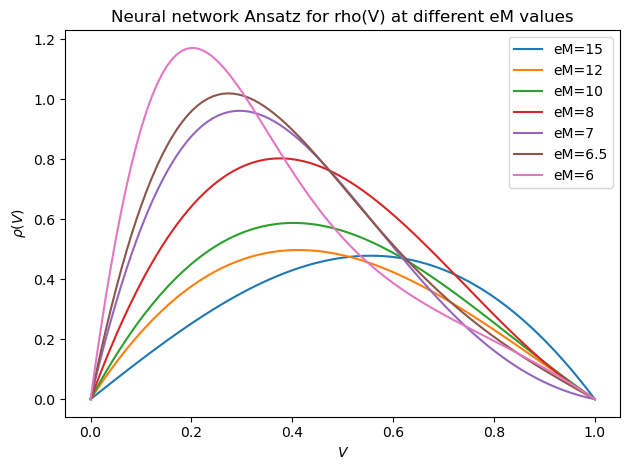

In [50]:
for eM, theta in theta_sols.items():
    rho_vals, drho_vals = rho_drho(np.linspace(0, 1, 100), theta, k=0)
    plt.plot(np.linspace(0, 1, 100), rho_vals, label=f"eM={eM}")
plt.xlabel(r"$V$")
plt.ylabel(r"$\rho(V)$")
plt.title("Neural network Ansatz for rho(V) at different eM values")
plt.legend()
plt.tight_layout()
plt.show()

#### $C^1$ Gluing

In [79]:
def AU_values(V_grid, r_vals, Q_vals):
    integrand = -Q_vals / (2 * r_vals**2)

    AU_vals = cumulative_simpson(
        integrand,
        x=V_grid,
        initial=0.0
    )

    return AU_vals

def solve_Phi_wave(theta, r, r_U, r_V, Q, A_U, eM, m):
    V_grid = np.linspace(0, 1, len(r))
    rho, drho = rho_drho(V_grid, theta, k=1)
    e = eM

    a_vals = rho * np.cos(V_grid)
    b_vals = -rho * np.sin(V_grid)

    aV_vals = drho * np.cos(V_grid) - rho * np.sin(V_grid)
    bV_vals = -drho * np.sin(V_grid) - rho * np.cos(V_grid)

    integrand_X = -r_U*aV_vals - (e*Q/(4*r))*b_vals + e*A_U*r_V*b_vals + e*A_U*r*bV_vals - (m**2/4)*r*a_vals
    integrand_Y = -r_U*bV_vals + (e*Q/(4*r))*a_vals - e*A_U*r_V*a_vals - e*A_U*r*aV_vals - (m**2/4)*r*b_vals
    
    rX_1 = simpson(integrand_X, V_grid)
    rY_1 = simpson(integrand_Y, V_grid)
    return rX_1 / r[-1], rY_1 / r[-1]

In [80]:
def loss_C1(theta, eM, q, lam=0.0, m_over_e = 0.0, w_Q=1.0, w_1 = 1.0, w_penalty=1.0, delta_pen=1e-3):
    xi_vals, xip_vals, _ = xi_integral(theta, k=1)

    inf_xi = np.min(xi_vals)

    # Avoid calculating r_U when r is zero or negative.
    if inf_xi <= 1e-8 or not np.all(np.isfinite(xi_vals)):
        return 1e6 + 1e6 * (1e-8 - inf_xi)**2

    out = sup_rU_for_q_lambda_massive(
        theta=theta,
        k=1,
        xi_vals=xi_vals,
        xip_vals=xip_vals,
        q=q,
        lam=lam,
        m_over_e=m_over_e,
        eM=eM,
    )

    residual = out["charge_residual"]

    penalty = w_penalty * (
        penalty_xi(xi_vals, delta=delta_pen)
        + penalty_rU(out["rU_vals"], delta=delta_pen)
    )
    V_grid = np.linspace(0.0, 1.0, len(xi_vals))
    r_vals = xi_vals * out["r_plus"]
    rV_vals = xip_vals * out["r_plus"]
    rU_vals = out["rU_vals"]
    Q_vals = out["Q_vals"]

    AU_vals = AU_values(
        V_grid,
        r_vals,
        Q_vals
    )
    
    re_phi_u, im_phi_u = solve_Phi_wave(
        theta=theta,
        r=r_vals,
        r_U=rU_vals,
        r_V=rV_vals,
        Q=Q_vals,
        A_U=AU_vals,
        eM=eM,
        m = m_over_e,
    )

    return w_Q * residual**2 + w_1 * (re_phi_u**2 + im_phi_u**2) + penalty

In [81]:
def C1_adam(theta_init, eM, q, lam=0.0, m_over_e = 0.0, w_Q=1.0, w_1 = 1.0, w_penalty=1000.0, lr=1e-3, eps=1e-5, delta_pen = 1e-3, max_iter=100):
    theta = torch.tensor(theta_init, dtype=torch.float64)
    optimizer = torch.optim.Adam([theta], lr=lr)
    loss_fn = lambda theta_np: loss_C1(theta_np, eM, q, lam=lam, m_over_e=m_over_e, w_Q=w_Q, w_1=w_1, w_penalty=w_penalty, delta_pen=delta_pen)
    best_loss = np.inf
    best_theta = None
    
    for iteration in range(max_iter):
        theta_np = np.asarray(
                    theta.detach().cpu().tolist(),
                    dtype=np.float64,
                )
        loss = loss_fn(theta_np)
        if loss < best_loss:
            best_loss = loss
            best_theta = theta_np.copy()
        
        grad_np = finite_difference_gradient(loss_fn, theta_np, eps=eps)
        optimizer.zero_grad(set_to_none=True)
        theta.grad = torch.tensor(
            grad_np.tolist(),
            dtype=theta.dtype,
            device=theta.device,
        )
        optimizer.step()
        
        if iteration % 20 == 0:
            print(
                f"step = {iteration:4d}, "
                f"loss = {loss:.6e}, "
                f"|gradient| = {np.linalg.norm(grad_np):.6e}"
            )
    return best_theta, best_loss

In [ ]:
p = 4

theta0 = init_theta(p, seed=None)
theta_sol_C1 = {100: np.array([ 3.46911344, -8.76098914, -4.74398299, -3.37642006,  
                               8.43179932, 22.20269577,
 11.88592317, -9.95764579,
 6.30353107, -6.38542192, -6.97998153, -5.20400069,
 -3.42912163]),
90: np.array([3.7183286, -8.66792528, -4.53983478, -3.62564477, 
              8.38133702, 22.04656428, 11.88472726, -10.07011993,   
              6.30813013,  -6.45243553, -6.89258982,  -5.38646774,  -3.53462193]),
80: np.array([4.12032262, -8.53030638, -4.34356462, -4.02764241, 
              8.29219385, 21.85671235, 11.9396392, -10.18046848, 
              6.41981174, -6.45739156, -6.62251942, -5.58894353, -3.71336989])}

In [130]:
eM = 78

theta_best, loss_best = C1_adam(
    theta_init=theta_sol_C1[80],
    eM=eM,
    q=1.0,
    lam=0.0,
    max_iter=500,
    lr=1e-3,
    delta_pen=1e-3
)

step =    0, loss = 1.427402e-03, |gradient| = 1.051478e+00
step =   20, loss = 6.687749e-04, |gradient| = 2.428806e-02
step =   40, loss = 5.883612e-04, |gradient| = 2.220314e-02
step =   60, loss = 5.191850e-04, |gradient| = 2.303898e-02
step =   80, loss = 4.682984e-04, |gradient| = 4.583136e-02
step =  100, loss = 4.201933e-04, |gradient| = 1.052115e-02
step =  120, loss = 3.769341e-04, |gradient| = 1.657260e-02
step =  140, loss = 3.377728e-04, |gradient| = 7.218612e-03
step =  160, loss = 3.035355e-04, |gradient| = 4.215983e-03
step =  180, loss = 2.741439e-04, |gradient| = 3.820051e-03
step =  200, loss = 2.493120e-04, |gradient| = 3.492945e-03
step =  220, loss = 2.285576e-04, |gradient| = 3.231171e-03
step =  240, loss = 2.112952e-04, |gradient| = 2.913454e-03
step =  260, loss = 1.969150e-04, |gradient| = 2.671532e-03
step =  280, loss = 1.848380e-04, |gradient| = 2.471546e-03
step =  300, loss = 1.745510e-04, |gradient| = 2.307163e-03
step =  320, loss = 1.656237e-04, |gradi

In [131]:
xi_vals, xip_vals, I = xi_integral(theta_best, k=1)
out = sup_rU_for_q_lambda_massive(
    theta=theta_best,
    k=1,
    xi_vals=xi_vals,
    xip_vals=xip_vals,
    q=1,
    lam=0,
    m_over_e=0.0,
    eM=eM
)

print("best loss:", loss_best)
print("charge residual:", out["charge_residual"])
print("inf xi:", np.min(xi_vals))
print("sup rU:", out["sup_rU"])
grad_best = finite_difference_gradient(
    lambda x: loss_C1(
        x,
        eM=eM,
        q=1.0,
        lam=0.0,
        w_Q=1.0,
        w_penalty=1.0,
        delta_pen=1e-3
    ),
    theta_best,
    eps=1e-6,
)

print("xi penalty:", penalty_xi(xi_vals))
print("rU penalty:", penalty_rU(out["rU_vals"]))
print(theta_best)

best loss: 0.00011249451043727884
charge residual: -0.0066899618695417384
inf xi: 0.0009873112490912939
sup rU: -0.07862559652103394
xi penalty: 1.6100439962319133e-10
rU penalty: 0.0
[  4.1906602   -8.51827527  -4.37066081  -4.09797994   8.21816035
  21.83004802  11.95084208 -10.21037413   6.41043321  -6.4472326
  -6.5734452   -5.71915992  -3.72931168]


In [132]:
result = opt.minimize(
    fun=lambda th: loss_C1(
        th,
        eM=eM,
        q=1.0,
        lam=0.0,
        w_Q=1.0,
        w_penalty=1000.0,
        delta_pen=1e-5
    ),
    x0=theta_best,
    method="BFGS",
    options={
        "maxiter": 1000,
        "gtol": 1e-9,
        "disp": True,
    },
)

theta_bfgs = result.x
print(theta_bfgs)

         Current function value: 0.000093
         Iterations: 7
         Function evaluations: 1967
         Gradient evaluations: 139
[  4.19482214  -8.51711947  -4.36610962  -4.10214191   8.21906807
  21.82804413  11.9515349  -10.21037413   6.41442675  -6.44746478
  -6.5667092   -5.71915995  -3.73088356]


/opt/anaconda3/envs/srim/lib/python3.12/site-packages/scipy/optimize/_minimize.py:780: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [93]:
def validate_C1(
    theta,
    eM,
    q,
    lam=0.0,
    m_over_e=0.0,
    charge_tol=1e-6,
    phi_tol=1e-6,
    xi_margin=0.0,
    rU_margin=0.0,
):
    xi_vals, xip_vals, I = xi_integral(theta, k=1)

    if not np.all(np.isfinite(xi_vals)):
        raise ValueError("xi contains non-finite values.")

    out = sup_rU_for_q_lambda_massive(
        theta=theta,
        k=1,
        xi_vals=xi_vals,
        xip_vals=xip_vals,
        q=q,
        lam=lam,
        m_over_e=m_over_e,
        eM=eM,
    )

    V_grid = np.linspace(0.0, 1.0, len(xi_vals))

    r_plus = out["r_plus"]
    r_vals = r_plus * xi_vals
    rV_vals = r_plus * xip_vals
    rU_vals = out["rU_vals"]
    Q_vals = out["Q_vals"]

    AU_vals = AU_values(
        V_grid,
        r_vals,
        Q_vals,
    )

    re_phi_u, im_phi_u = solve_Phi_wave(
        theta=theta,
        r=r_vals,
        r_U=rU_vals,
        r_V=rV_vals,
        Q=Q_vals,
        A_U=AU_vals,
        eM=eM,
        m=m_over_e * eM,
    )

    # Works whether solve_Phi_wave returns arrays or endpoint scalars.
    re_phi_u_1 = np.asarray(re_phi_u).reshape(-1)[-1]
    im_phi_u_1 = np.asarray(im_phi_u).reshape(-1)[-1]

    charge_residual = out["charge_residual"]
    inf_xi = np.min(xi_vals)
    sup_rU = out["sup_rU"]

    print(f"charge residual = {charge_residual:.12e}")
    print(f"Re Phi_U(1)     = {re_phi_u_1:.12e}")
    print(f"Im Phi_U(1)     = {im_phi_u_1:.12e}")
    print(f"inf xi          = {inf_xi:.12e}")
    print(f"sup rU          = {sup_rU:.12e}")
    print(f"I               = {I:.12e}")

    valid = (
        abs(charge_residual) <= charge_tol
        and abs(re_phi_u_1) <= phi_tol
        and abs(im_phi_u_1) <= phi_tol
        and inf_xi > xi_margin
        and sup_rU < -rU_margin
    )

    print("valid C1 solution:", valid)

    return {
        "valid": valid,
        "charge_residual": charge_residual,
        "re_phi_u_1": re_phi_u_1,
        "im_phi_u_1": im_phi_u_1,
        "inf_xi": inf_xi,
        "sup_rU": sup_rU,
        "I": I,
    }

In [133]:
diagnostics = validate_C1(
    theta_bfgs,
    eM=eM,
    q=1.0,
    lam=0.0,
    charge_tol=1e-6,
    phi_tol=1e-6,
)

charge residual = -6.014334286281e-03
Re Phi_U(1)     = 6.499756623222e-03
Im Phi_U(1)     = -3.813164372699e-03
inf xi          = 9.053495296507e-07
sup rU          = -7.865912190008e-02
I               = 1.274340597069e-02
valid C1 solution: False


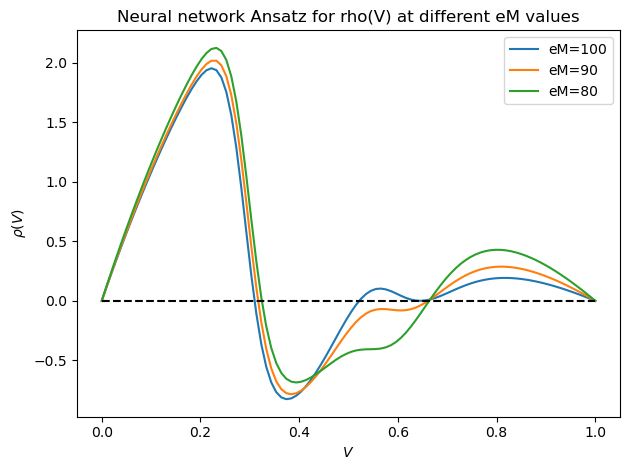

In [138]:
for eM, theta in theta_sol_C1.items():
    rho_vals, drho_vals = rho_drho(np.linspace(0, 1, 100), theta, k=0)
    plt.plot(np.linspace(0, 1, 100), rho_vals, label=f"eM={eM}")
plt.xlabel(r"$V$")
plt.hlines(0, 0, 1, colors="k", linestyles="--")
plt.ylabel(r"$\rho(V)$")
plt.title("Neural network Ansatz for rho(V) at different eM values")
plt.legend()
plt.tight_layout()
plt.show()

#### Training Phase as well
Let $\Phi(V)=\rho(V)e^{-i\omega(V)}$ where 
$$\omega(V)=\frac{\int_0^Ve^{g(s)}ds}{\int_0^1e^{g(s)}ds}$$
with 
$$g(V)=a_0+\sum_{j=1}^pa_j\tanh(w_jV+b_j).$$

In [167]:
def omega_domega(V, theta):
    '''Neural network Ansatz for omega and its derivative.'''
    n_grid = 5001
    a0, a, w, b = unpack_theta(theta)
    V_arr = np.asarray(V, dtype=float)
    def network(x):
        x = np.asarray(x, dtype=float)
        z = x[..., None] * w + b
        return a0 + np.sum(a * np.tanh(z), axis=-1)

    # Evaluate the phase speed on a fixed integration grid
    grid = np.linspace(0.0, 1.0, n_grid)
    g_grid = network(grid)

    # Subtracting a constant does not change the normalised Ansatz,
    # and prevents overflow in exp.
    shift = np.max(g_grid)
    speed_grid = np.exp(g_grid - shift)

    # Cumulative integral from 0 to each grid point
    cumulative = cumulative_simpson(
        speed_grid,
        x=grid,
        initial=0.0,
    )
    normalisation = cumulative[-1]
    # Interpolate the cumulative integral at the requested V values
    omega = np.interp(
        V_arr.ravel(),
        grid,
        cumulative,
    ).reshape(V_arr.shape) / normalisation

    # Analytic expression for omega'
    domega = np.exp(network(V_arr) - shift) / normalisation

    # Preserve scalar input behaviour
    if V_arr.ndim == 0:
        return float(omega), float(domega)

    return omega, domega

In [168]:
def xi_integral_new(theta_1, theta_2, k):

    # Precompute phase normalisation once
    a0, a, w, b = unpack_theta(theta_2)
    V_phase = np.linspace(0, 1, 5001)

    z_phase = V_phase[..., None] * w + b
    NN_phase = a0 + np.sum(a * np.tanh(z_phase), axis=-1)

    # Shift prevents overflow; it cancels in the normalised expression
    shift = np.max(NN_phase)
    normali = simpson(np.exp(NN_phase - shift), x=V_phase)

    def domega_fast(V):
        V = np.asarray(V, dtype=float)
        z = V[..., None] * w + b
        NN = a0 + np.sum(a * np.tanh(z), axis=-1)
        return np.exp(NN - shift) / normali

    def f(V, y):
        xi, xip = y
        rho, drho = rho_drho(V, theta_1, k=k)
        domega = domega_fast(V)

        return [
            xip,
            -xi * (drho**2 + (domega * rho)**2)
        ]

    V_grid = np.linspace(0, 1, 5001)

    sol = solve_ivp(
        f,
        t_span=(1.0, 0.0),
        y0=[1.0, 0.0],
        t_eval=V_grid[::-1],
        method="DOP853",
        rtol=1e-10,
        atol=1e-12
    )

    xi_vals = sol.y[0][::-1]
    xip_vals = sol.y[1][::-1]

    rho_vals = rho_drho(V_grid, theta_1, k=k)[0]
    domega_vals = domega_fast(V_grid)

    I = simpson(
        xi_vals**2 * rho_vals**2 * domega_vals,
        x=V_grid
    )

    return xi_vals, xip_vals, I

In [169]:
def var_values_new(
    theta_1,
    theta_2,
    k,
    xi_vals,
    xip_vals,
    q,
    lam,
    m_over_e=0.0,
    eM=None,
):
    V_grid = np.linspace(0.0, 1.0, len(xi_vals))
    r_plus, Qtarget = rplus_and_Qtarget(q, lam)

    r_vals = r_plus * xi_vals
    rp_vals = r_plus * xip_vals

    rho_vals, _ = rho_drho(V_grid, theta_1, k)
    _, domega_vals = omega_domega(V_grid, theta_2)

    integrand_I = xi_vals**2 * rho_vals**2 * domega_vals

    cum_I = cumulative_simpson(
        integrand_I,
        x=V_grid,
        initial=0.0
    )
    I_a = cum_I[-1]

    if eM is None:
        e = Qtarget / (r_plus**2 * I_a)
    else:
        e = eM

    m = m_over_e * e

    if eM is None:
        Q_vals = Qtarget * cum_I / cum_I[-1]
    else:
        Q_vals = e * r_plus**2 * cum_I

    charge_residual = Q_vals[-1] - Qtarget

    rU0 = (lam * r_vals[0]**2 / 3.0 - 1.0) / (4.0 * rp_vals[0])
    
    integrand_rU = (
        -0.25
        + Q_vals**2 / (4.0 * r_vals**2)
        + lam * r_vals**2 / 4.0
        + m**2 * r_vals**2 * rho_vals**2 / 4.0
    )

    r_rU_vals = (
        r_vals[0] * rU0
        + cumulative_simpson(
            integrand_rU,
            x=V_grid,
            initial=0.0
        )
    )

    rU_vals = r_rU_vals / r_vals

    return {
        "sup_rU": np.max(rU_vals),
        "rU_vals": rU_vals,
        "Q_vals": Q_vals,
        "r_plus": r_plus,
        "Qtarget": Qtarget,
        "I_theta": I_a,
        "e": e,
        "m": m,
        "m_over_e": m_over_e,
        "charge_residual": charge_residual,
    }

In [170]:
def loss_C0_new(theta_1, theta_2, eM, q, lam=0.0, w_Q=1.0, w_penalty=1.0, delta_pen=1e-3):
    xi_vals, xip_vals, _ = xi_integral_new(theta_1, theta_2, k=0)

    inf_xi = np.min(xi_vals)

    # Avoid calculating r_U when r is zero or negative.
    if inf_xi <= 1e-8 or not np.all(np.isfinite(xi_vals)):
        return 1e6 + 1e6 * (1e-8 - inf_xi)**2

    out = var_values_new(
        theta_1=theta_1,
        theta_2=theta_2,
        k=0,
        xi_vals=xi_vals,
        xip_vals=xip_vals,
        q=q,
        lam=lam,
        m_over_e=0.0,
        eM=eM,
    )

    residual = out["charge_residual"]

    penalty = w_penalty * (
        penalty_xi(xi_vals, delta=delta_pen)
        + penalty_rU(out["rU_vals"], delta=delta_pen)
    )

    return w_Q * residual**2 + penalty

In [171]:
def C0_adam_new(
    theta_init_1,
    theta_init_2,
    eM,
    q,
    lam=0.0,
    w_Q=1.0,
    w_penalty=1000.0,
    lr=1e-3,
    eps=1e-5,
    delta_pen=1e-3,
    max_iter=100,
):
    len_theta_1 = len(theta_init_1)

    theta_init = np.concatenate([
        theta_init_1,
        theta_init_2
    ])

    theta = torch.tensor(
        theta_init,
        dtype=torch.float64,
        requires_grad=True,
    )

    optimizer = torch.optim.Adam([theta], lr=lr)

    loss_fn = lambda theta_np_1, theta_np_2: loss_C0_new(
        theta_np_1,
        theta_np_2,
        eM,
        q,
        lam=lam,
        w_Q=w_Q,
        w_penalty=w_penalty,
        delta_pen=delta_pen,
    )

    best_loss = np.inf
    best_theta = None

    for iteration in range(max_iter):
        theta_np = theta.detach().cpu().numpy().copy()

        loss = loss_fn(
            theta_np[:len_theta_1],
            theta_np[len_theta_1:],
        )

        if loss < best_loss:
            best_loss = loss
            best_theta = theta_np.copy()

        grad_np = finite_difference_gradient(
            lambda theta_np: loss_fn(
                theta_np[:len_theta_1],
                theta_np[len_theta_1:],
            ),
            theta_np,
            eps=eps,
        )

        optimizer.zero_grad(set_to_none=True)

        theta.grad = torch.from_numpy(grad_np).to(
            dtype=theta.dtype,
            device=theta.device,
        )

        optimizer.step()

        if iteration % 20 == 0:
            print(
                f"step = {iteration:4d}, "
                f"loss = {loss:.6e}, "
                f"|gradient| = {np.linalg.norm(grad_np):.6e}"
            )

    best_theta_1 = best_theta[:len_theta_1]
    best_theta_2 = best_theta[len_theta_1:]

    return best_theta_1, best_theta_2, best_loss

In [283]:
theta0 = init_theta(p, seed=None)
theta_1_sols = {6.5: np.array([1.70119973, -2.22396187, -2.36007754,  3.31053625,  2.03618497, -0.46773596,
 -0.16037078, -2.31878507, -2.25239546, -1.27617053, -1.44370288,  0.52174226,
  0.45000031]), 
                6: np.array([ 1.82373941, -2.32503876, -2.4829092,   3.48271069,  2.20856398, -0.31283808,
 -0.02873718, -2.4913518,  -2.42940095, -1.41323117, -1.56165965,  0.45599756,
  0.43281202]),
                5.5: np.array([ 1.99194558, -2.49482158, -2.65437005,  3.72932997,  2.4552612, -0.12440285,
  0.05719524, -2.74413273, -2.68164156, -1.5637677,  -1.69329548,  0.41654949,
  0.39558533]),
                5: np.array([ 2.19099369, -2.69625119, -2.85575582,  4.02845736,  2.75436616,
        0.05996213,  0.10118538, -3.05750676, -2.98851245, -1.74006976,
       -1.86087598,  0.40786215,  0.38849537]),
                4.5: np.array([ 2.41690957, -2.9248343 , -3.08416025,  4.35113884,  3.07716942,
        0.2129017 ,  0.23806125, -3.39854119, -3.31705174, -1.92064625,
       -2.03328878,  0.42074693,  0.40179562]),
                4: np.array([ 2.71905059, -3.2304291 , -3.38937325,  4.70467566,  3.4285396 ,
        0.61493543,  0.64887759, -3.82365606, -3.71817783, -2.10460966,
       -2.20078051,  0.43818779,  0.416468  ]),
                3.8: np.array([ 2.88595203, -3.3974683 , -3.55640934,  4.90208363,  3.62635616,
        0.77826262,  0.82156792, -4.02440111, -3.91894695, -2.21725653,
       -2.2236295 ,  0.46376633,  0.43659877]),
                3.6: np.array([ 3.03235507, -3.54364719, -3.70253933,  5.11401899,  3.83705507,
        0.9124542 ,  0.96190442, -4.25073016, -4.14104083, -2.3738223 ,
       -2.30503256,  0.48384411,  0.43110693])}
theta_2_sols = {6.5: np.array([ 1.46917513e-05,  1.53138303e+00,  1.18374367e+00, -4.81469987e-01,
 -1.45225153e+00,  6.51241980e-01, -3.22411328e-02, -2.17604492e-01,
  6.71501634e-01, -6.42955242e-02,  1.91269283e-02, -4.56767554e-02,
 -1.62267016e-01]),
                6: np.array([ 1.66747412e-05,  1.39481685e+00,  1.41146171e+00, -3.65688744e-01,
 -1.61188021e+00,  5.07174519e-01, -1.88530134e-01, -7.92548170e-02,
  8.24744829e-01,  7.35525709e-02,  1.71071167e-01, -1.54397001e-01,
 -3.29136068e-01]),
                5.5: np.array([ 1.13500817e-05,  1.24037311e+00,  1.64123234e+00, -4.03940668e-01,
 -1.81920577e+00,  3.50924742e-01, -3.94683513e-01,  1.06167664e-01,
  1.02384895e+00,  2.38378990e-01,  4.66709572e-01, -1.69356076e-01,
 -5.74199731e-01]),
                5: np.array([ 2.87711566e-06,  1.36872546e+00,  1.90086193e+00, -6.79515498e-01,
       -2.08349958e+00,  7.54697261e-01, -6.71506127e-01,  3.68134336e-01,
        1.30965289e+00,  4.23081718e-01,  8.28002510e-01, -6.39372968e-01,
       -8.93437346e-01]),
                4.5: np.array([-8.90855769e-07,  1.77601464e+00,  2.20798568e+00, -1.00222732e+00,
       -2.40177045e+00,  1.15469696e+00, -1.00973938e+00,  7.18966878e-01,
        1.67232706e+00,  2.10442849e-01,  1.12516332e+00, -1.01862617e+00,
       -1.21940844e+00]),
                4: np.array([ 1.43855100e-05,  2.22164752e+00,  2.55364453e+00, -1.35714263e+00,
       -2.76796420e+00,  1.64869642e+00, -1.41741768e+00,  1.10821877e+00,
        2.12198942e+00,  7.76876951e-02,  1.36710701e+00, -1.31819691e+00,
       -1.51307576e+00]),
                3.8: np.array([ 9.89938415e-06,  2.42746831e+00,  2.74969045e+00, -1.55768864e+00,
       -2.96206318e+00,  1.85289112e+00, -1.61545698e+00,  1.31067619e+00,
        2.32296911e+00,  2.22072974e-03,  1.49352358e+00, -1.46531181e+00,
       -1.63999033e+00]),
                3.6: np.array([ 1.12350894e-05,  2.68809479e+00,  2.97984378e+00, -1.78791532e+00,
       -3.19435503e+00,  2.11562708e+00, -1.85617649e+00,  1.55224709e+00,
        2.56795135e+00, -4.63088556e-02,  1.60145889e+00, -1.60033920e+00,
       -1.72607577e+00])}

'''
,
                3.61: np.array([ 3.02696009, -3.53825347, -3.69714632,  5.10910123,  3.83243152,
        0.00553338, -0.00554834,  0.90733318,  0.95679743, -4.25702595,
       -4.14730693,  0.62597108, -0.39837396, -2.36782877, -2.30156943,
        0.47807765,  0.42536771, -0.2548024 ,  0.14643422])

,
                3.61: np.array([ 1.12126480e-05,  2.69334062e+00,  2.98006884e+00, -1.78757831e+00,
       -3.19530759e+00,  1.05171682e-02, -9.54028181e-03,  2.11948425e+00,
       -1.85730629e+00,  1.55324169e+00,  2.56920985e+00,  6.26821969e-01,
       -4.06087202e-01, -4.79714510e-02,  1.60413744e+00, -1.60311168e+00,
       -1.72860974e+00, -3.17136269e-01,  2.11042310e-01])


'''


'\n,\n                3.61: np.array([ 3.02696009, -3.53825347, -3.69714632,  5.10910123,  3.83243152,\n        0.00553338, -0.00554834,  0.90733318,  0.95679743, -4.25702595,\n       -4.14730693,  0.62597108, -0.39837396, -2.36782877, -2.30156943,\n        0.47807765,  0.42536771, -0.2548024 ,  0.14643422])\n\n,\n                3.61: np.array([ 1.12126480e-05,  2.69334062e+00,  2.98006884e+00, -1.78757831e+00,\n       -3.19530759e+00,  1.05171682e-02, -9.54028181e-03,  2.11948425e+00,\n       -1.85730629e+00,  1.55324169e+00,  2.56920985e+00,  6.26821969e-01,\n       -4.06087202e-01, -4.79714510e-02,  1.60413744e+00, -1.60311168e+00,\n       -1.72860974e+00, -3.17136269e-01,  2.11042310e-01])\n\n\n'

In [247]:
# t1_tmp = np.array([ 3.0186225 , -3.53007799, -3.68902262,  5.08686553,  3.81251409,
#         0.8865691 ,  0.94637587, -4.19840341, -4.09484   , -2.33341461,
#        -2.28449499,  0.4637423 ,  0.4372444 ])
# t2_tmp = np.array([ 1.04638494e-05,  2.62821844e+00,  2.92115686e+00, -1.73629681e+00,
#        -3.13100794e+00,  2.04492569e+00, -1.79191296e+00,  1.49795846e+00,
#         2.50126912e+00, -3.75389066e-02,  1.56961302e+00, -1.56073921e+00,
#        -1.69795267e+00])
def generate_seed(theta_1, theta_2, p, seed=None):
    a0_1, a_1, w_1, b_1 = unpack_theta(theta_1)
    a0_2, a_2, w_2, b_2 = unpack_theta(theta_2)
    rng = np.random.default_rng(seed)
    delta_p = p - len(a_1)
    if delta_p == 0:
        return theta_1, theta_2
    w_extra = rng.normal(size=delta_p)
    b_extra = -0.5 * w_extra
    theta_1_new = np.concatenate([[a0_1], a_1, np.zeros(delta_p), w_1, w_extra, b_1, b_extra])
    theta_2_new = np.concatenate([[a0_2], a_2, np.zeros(delta_p), w_2, w_extra, b_2, b_extra])
    return theta_1_new, theta_2_new

p6_theta_1_36, p6_theta_2_36 = generate_seed(theta_1_sols[3.6], theta_2_sols[3.6], p=6)
    

In [258]:
# after 500 iter, reduced delta to 1e-4 and repeated once more for eM=3.5
eM = 3.4

theta_1_best, theta_2_best, loss_best = C0_adam_new(
    theta_init_1=theta_1_sols[3.61],
    theta_init_2=theta_2_sols[3.61],
    eM=eM,
    q=1.0,
    lam=0.0,
    max_iter=500,
    lr=1e-3,
    delta_pen=1e-4
)

step =    0, loss = 3.086420e-03, |gradient| = 1.013863e-02
step =   20, loss = 2.923534e-03, |gradient| = 8.903044e-03
step =   40, loss = 2.962802e-03, |gradient| = 9.586576e-03
step =   60, loss = 2.968802e-03, |gradient| = 9.698385e-03


KeyboardInterrupt: 

In [253]:
n1 = len(theta_1_best)

x0 = np.concatenate([theta_1_best, theta_2_best])

result = opt.minimize(
    fun=lambda th: loss_C0_new(
        th[:n1],
        th[n1:],
        eM=eM,
        q=1.0,
        lam=0.0,
        w_Q=1.0,
        w_penalty=1000.0,
        delta_pen=1e-6,
    ),
    x0=x0,
    method="BFGS",
    options={
        "maxiter": 1000,
        "gtol": 1e-9,
        "disp": True,
    },
)

theta_1_bfgs = result.x[:n1]
theta_2_bfgs = result.x[n1:]

print(theta_1_bfgs)
print(theta_2_bfgs)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 0
         Function evaluations: 39
         Gradient evaluations: 1
[ 3.02696009 -3.53825347 -3.69714632  5.10910123  3.83243152  0.00553338
 -0.00554834  0.90733318  0.95679743 -4.25702595 -4.14730693  0.62597108
 -0.39837396 -2.36782877 -2.30156943  0.47807765  0.42536771 -0.2548024
  0.14643422]
[ 1.12126480e-05  2.69334062e+00  2.98006884e+00 -1.78757831e+00
 -3.19530759e+00  1.05171682e-02 -9.54028181e-03  2.11948425e+00
 -1.85730629e+00  1.55324169e+00  2.56920985e+00  6.26821969e-01
 -4.06087202e-01 -4.79714510e-02  1.60413744e+00 -1.60311168e+00
 -1.72860974e+00 -3.17136269e-01  2.11042310e-01]


In [251]:
xi_vals, xip_vals, I = xi_integral_new(
    theta_1_bfgs,
    theta_2_bfgs,
    k=0,
)


out = var_values_new(
    theta_1_bfgs,
    theta_2_bfgs,
    0,
    xi_vals,
    xip_vals,
    q=1.0,
    lam=0.0,
    eM=eM,
)

V_grid = np.linspace(0.0, 1.0, len(xi_vals))
omega_vals, domega_vals = omega_domega(V_grid, theta_2_bfgs)

print("charge residual =", out["charge_residual"])
print("inf xi          =", np.min(xi_vals))
print("sup rU          =", out["sup_rU"])
print("omega(0), omega(1) =", omega_vals[0], omega_vals[-1])
print("min/max omega'  =", np.min(domega_vals), np.max(domega_vals))
print("integral omega' =", simpson(domega_vals, x=V_grid))

charge residual = -0.04905938869324389
inf xi          = 0.0012658896729942776
sup rU          = -0.06051446502451351
omega(0), omega(1) = 0.0 1.0
min/max omega'  = 0.0007037008384335778 2.4973118810579296
integral omega' = 0.999999999999998


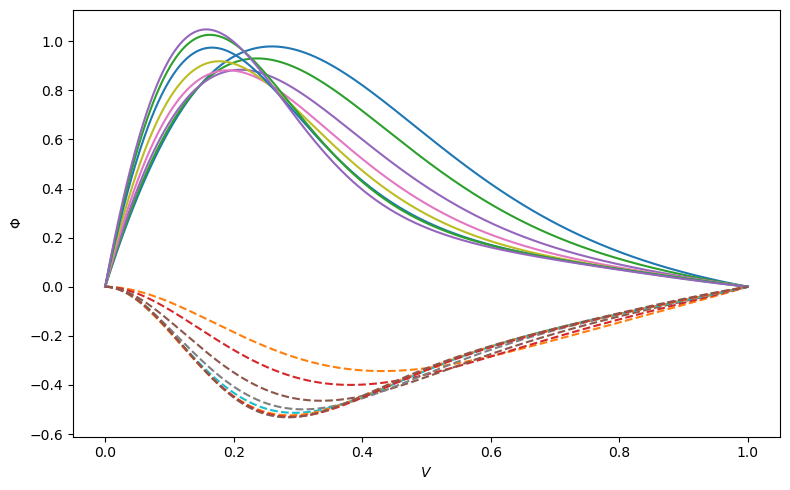

In [284]:
V_grid = np.linspace(0.0, 1.0, 5001)

plt.figure(figsize=(8, 5))

for eM, theta_1 in theta_1_sols.items():
    theta_2 = theta_2_sols[eM]

    rho_vals, _ = rho_drho(V_grid, theta_1, k=0)
    omega_vals, _ = omega_domega(V_grid, theta_2)

    Phi_vals = rho_vals * np.exp(-1j * omega_vals)

    plt.plot(
        V_grid,
        Phi_vals.real,
        label=fr"$\mathrm{{Re}}\,\Phi$, $eM={eM}$",
    )

    plt.plot(
        V_grid,
        Phi_vals.imag,
        "--",
        label=fr"$\mathrm{{Im}}\,\Phi$, $eM={eM}$",
    )

plt.xlabel(r"$V$")
plt.ylabel(r"$\Phi$")
plt.tight_layout()
plt.show()

In [ ]:
theta_2_bfgs

array([ 1.12126480e-05,  2.69334062e+00,  2.98006884e+00, -1.78757831e+00,
       -3.19530759e+00,  1.05171682e-02, -9.54028181e-03,  2.11948425e+00,
       -1.85730629e+00,  1.55324169e+00,  2.56920985e+00,  6.26821969e-01,
       -4.06087202e-01, -4.79714510e-02,  1.60413744e+00, -1.60311168e+00,
       -1.72860974e+00, -3.17136269e-01,  2.11042310e-01])

In [266]:
def solve_Phi_wave_new(theta_1, theta_2, r, r_U, r_V, Q, A_U, eM, m):
    V_grid = np.linspace(0, 1, len(r))

    rho, drho = rho_drho(V_grid, theta_1, k=1)
    omega, domega = omega_domega(V_grid, theta_2)

    e = eM

    a_vals = rho * np.cos(omega)
    b_vals = -rho * np.sin(omega)

    aV_vals = (
        drho * np.cos(omega)
        - rho * np.sin(omega) * domega
    )

    bV_vals = (
        -drho * np.sin(omega)
        - rho * np.cos(omega) * domega
    )

    integrand_X = (
        -r_U * aV_vals
        - (e * Q / (4 * r)) * b_vals
        + e * A_U * r_V * b_vals
        + e * A_U * r * bV_vals
        - (m**2 / 4) * r * a_vals
    )

    integrand_Y = (
        -r_U * bV_vals
        + (e * Q / (4 * r)) * a_vals
        - e * A_U * r_V * a_vals
        - e * A_U * r * aV_vals
        - (m**2 / 4) * r * b_vals
    )

    rX_1 = simpson(integrand_X, x=V_grid)
    rY_1 = simpson(integrand_Y, x=V_grid)

    return rX_1 / r[-1], rY_1 / r[-1]

In [ ]:
def loss_C1_new(theta_1, theta_2, eM, q, lam=0.0, m_over_e = 0.0, w_Q=1.0, w_1 = 1.0, w_penalty=1.0, delta_pen=1e-3):
    xi_vals, xip_vals, _ = xi_integral_new(theta_1, theta_2, k=1)

    inf_xi = np.min(xi_vals)

    # Avoid calculating r_U when r is zero or negative.
    if inf_xi <= 1e-8 or not np.all(np.isfinite(xi_vals)):
        return 1e6 + 1e6 * (1e-8 - inf_xi)**2

    out = var_values_new(
        theta_1=theta_1,
        theta_2=theta_2,
        k=1,
        xi_vals=xi_vals,
        xip_vals=xip_vals,
        q=q,
        lam=lam,
        m_over_e=m_over_e,
        eM=eM,
    )

    residual = out["charge_residual"]

    penalty = w_penalty * (
        penalty_xi(xi_vals, delta=delta_pen)
        + penalty_rU(out["rU_vals"], delta=delta_pen)
    )
    V_grid = np.linspace(0.0, 1.0, len(xi_vals))
    r_vals = xi_vals * out["r_plus"]
    rV_vals = xip_vals * out["r_plus"]
    rU_vals = out["rU_vals"]
    Q_vals = out["Q_vals"]

    AU_vals = AU_values(
        V_grid,
        r_vals,
        Q_vals
    )
    
    re_phi_u, im_phi_u = solve_Phi_wave_new(
        theta_1=theta_1,
        theta_2=theta_2,
        r=r_vals,
        r_U=rU_vals,
        r_V=rV_vals,
        Q=Q_vals,
        A_U=AU_vals,
        eM=eM,
        m = out["m"],
    )

    return w_Q * residual**2 + w_1 * (re_phi_u**2 + im_phi_u**2) + penalty

In [ ]:
def C1_adam_new(
    theta_1_init,
    theta_2_init,
    eM,
    q,
    lam=0.0,
    m_over_e=0.0,
    w_Q=1.0,
    w_1=1.0,
    w_penalty=1000.0,
    lr=1e-3,
    eps=1e-5,
    delta_pen=1e-3,
    max_iter=100,
):
    len_theta_1 = len(theta_1_init)

    theta_init = np.concatenate([theta_1_init, theta_2_init,])
    theta = torch.tensor(theta_init, dtype=torch.float64, requires_grad=True,)
    optimizer = torch.optim.Adam([theta], lr=lr)

    def loss_flat(theta_np):
        return loss_C1_new(
            theta_1=theta_np[:len_theta_1],
            theta_2=theta_np[len_theta_1:],
            eM=eM,
            q=q,
            lam=lam,
            m_over_e=m_over_e,
            w_Q=w_Q,
            w_1=w_1,
            w_penalty=w_penalty,
            delta_pen=delta_pen,
        )

    best_loss = np.inf
    best_theta = theta_init.copy()

    for iteration in range(max_iter):
        theta_np = theta.detach().cpu().numpy().copy()

        loss = loss_flat(theta_np)

        if np.isfinite(loss) and loss < best_loss:
            best_loss = loss
            best_theta = theta_np.copy()

        grad_np = finite_difference_gradient(
            loss_flat,
            theta_np,
            eps=eps,
        )

        if not np.all(np.isfinite(grad_np)):
            print(f"Stopping at step {iteration}: non-finite gradient.")
            break

        optimizer.zero_grad(set_to_none=True)

        theta.grad = torch.from_numpy(grad_np).to(
            dtype=theta.dtype,
            device=theta.device,
        )

        optimizer.step()

        if iteration % 20 == 0:
            print(
                f"step = {iteration:4d}, "
                f"loss = {loss:.6e}, "
                f"|gradient| = {np.linalg.norm(grad_np):.6e}"
            )

    best_theta_1 = best_theta[:len_theta_1]
    best_theta_2 = best_theta[len_theta_1:]

    return best_theta_1, best_theta_2, best_loss

In [297]:
eM = 85
def fixed_phase_seed(p, seed=0):
    rng = np.random.default_rng(seed)

    a0 = 0.0
    a = np.zeros(p)

    w = rng.normal(size=p)
    b = -0.5 * w

    return np.concatenate([
        [a0],
        a,
        w,
        b,
    ])
theta_2_seed = fixed_phase_seed(p, seed=0)

In [298]:
theta_1_best, theta_2_best, loss_best = C1_adam_new(
    theta_1_init=np.array([  3.72106371,  -8.66776671,  -4.53902929,  -3.62837987,
         8.3815827 ,  22.04576139,  11.88450447, -10.07435195,
         6.30009296,  -6.45205559,  -6.89176691,  -5.39448044,
        -3.53439805]),
    theta_2_init=np.array([-3.17833534e-09, -9.92987675e-03,  9.92219045e-03, -9.79794876e-03,
       -9.96121165e-03,  1.38784725e-01, -1.45158606e-01,  6.53466238e-01,
        1.17957745e-01, -7.40936166e-02,  7.73926750e-02, -3.33045866e-01,
       -6.32276150e-02]),
    eM=eM,
    q=1.0,
    lam=0.0,
    max_iter=100,
    lr=5e-4,
    delta_pen=1e-4,
    w_penalty=100.0,
    eps=1e-4 #important
)

step =    0, loss = 2.618438e-03, |gradient| = 6.048205e-02
step =   20, loss = 2.687633e-03, |gradient| = 9.142890e-02
step =   40, loss = 2.670855e-03, |gradient| = 9.548150e-02


KeyboardInterrupt: 

In [304]:
n1 = len(theta_1_best)

x0 = np.concatenate([theta_1_best, theta_2_best])

result = opt.minimize(
    fun=lambda th: loss_C1_new(
        th[:n1],
        th[n1:],
        eM=eM,
        q=1.0,
        lam=0.0,
        w_Q=1.0,
        w_penalty=100.0,
        delta_pen=1e-4
    ),
    x0=x0,
    method="BFGS",
    options={
        "maxiter": 1000,
        "gtol": 1e-9,
        "disp": True,
    },
)

theta_1_bfgs = result.x[:n1]
theta_2_bfgs = result.x[n1:]

print(theta_1_bfgs)
print(theta_2_bfgs)

         Current function value: 0.002465
         Iterations: 2
         Function evaluations: 1519
         Gradient evaluations: 56
[  3.72266472  -8.66719948  -4.53917582  -3.62998089   8.38086067
  22.04513516  11.88496451 -10.07435194   6.29927948  -6.45303638
  -6.89019749  -5.39448044  -3.53662263]
[-3.17833809e-09 -1.03353967e-02  1.03463496e-02 -1.16908940e-02
 -1.03059356e-02  1.38814003e-01 -1.45187886e-01  6.53494799e-01
  1.17987085e-01 -7.40936516e-02  7.73927386e-02 -3.33047317e-01
 -6.32276334e-02]


/opt/anaconda3/envs/srim/lib/python3.12/site-packages/scipy/optimize/_minimize.py:780: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [295]:
theta_2_bfgs

array([-3.17833534e-09, -9.92987675e-03,  9.92219045e-03, -9.79794876e-03,
       -9.96121165e-03,  1.38784725e-01, -1.45158606e-01,  6.53466238e-01,
        1.17957745e-01, -7.40936166e-02,  7.73926750e-02, -3.33045866e-01,
       -6.32276150e-02])

In [289]:
def validate_C1_new(
    theta_1,
    theta_2,
    eM,
    q,
    lam=0.0,
    m_over_e=0.0,
    match_tol=1e-6,
    xi_tol=1e-8,
    rU_tol=1e-8,
    phase_tol=1e-8,
    verbose=True,
):
    """
    Validate a varying-phase C^1 gluing candidate.

    Returns
    -------
    valid : bool
        True if all matching and admissibility conditions pass.
    diagnostics : dict
        Numerical diagnostics for the candidate.
    """

    try:
        # Raychaudhuri and charge integral
        xi_vals, xip_vals, I = xi_integral_new(
            theta_1,
            theta_2,
            k=1,
        )

        if (
            not np.all(np.isfinite(xi_vals))
            or not np.all(np.isfinite(xip_vals))
            or not np.isfinite(I)
        ):
            raise FloatingPointError(
                "Non-finite values returned by xi_integral_new."
            )

        out = var_values_new(
            theta_1=theta_1,
            theta_2=theta_2,
            k=1,
            xi_vals=xi_vals,
            xip_vals=xip_vals,
            q=q,
            lam=lam,
            m_over_e=m_over_e,
            eM=eM,
        )

        V_grid = np.linspace(0.0, 1.0, len(xi_vals))

        r_vals = out["r_plus"] * xi_vals
        rV_vals = out["r_plus"] * xip_vals
        rU_vals = out["rU_vals"]
        Q_vals = out["Q_vals"]

        AU_vals = AU_values(
            V_grid,
            r_vals,
            Q_vals,
        )

        re_phi_u, im_phi_u = solve_Phi_wave_new(
            theta_1=theta_1,
            theta_2=theta_2,
            r=r_vals,
            r_U=rU_vals,
            r_V=rV_vals,
            Q=Q_vals,
            A_U=AU_vals,
            eM=eM,
            m=out["m"],
        )

        omega_vals, domega_vals = omega_domega(
            V_grid,
            theta_2,
        )

        arrays = {
            "r": r_vals,
            "rV": rV_vals,
            "rU": rU_vals,
            "Q": Q_vals,
            "AU": AU_vals,
            "omega": omega_vals,
            "domega": domega_vals,
        }

        all_finite = all(
            np.all(np.isfinite(values))
            for values in arrays.values()
        )

        charge_residual = float(out["charge_residual"])
        re_phi_u = float(re_phi_u)
        im_phi_u = float(im_phi_u)

        inf_xi = float(np.min(xi_vals))
        sup_rU = float(np.max(rU_vals))

        omega_0 = float(omega_vals[0])
        omega_1 = float(omega_vals[-1])
        min_domega = float(np.min(domega_vals))
        max_domega = float(np.max(domega_vals))
        integral_domega = float(
            simpson(domega_vals, x=V_grid)
        )

        # Individual checks
        charge_ok = abs(charge_residual) < match_tol

        re_phi_ok = abs(re_phi_u) < match_tol
        im_phi_ok = abs(im_phi_u) < match_tol
        C1_matching_ok = re_phi_ok and im_phi_ok

        xi_ok = inf_xi > xi_tol
        rU_ok = sup_rU < -rU_tol

        phase_endpoint_ok = (
            abs(omega_0) < phase_tol
            and abs(omega_1 - 1.0) < phase_tol
        )

        phase_integral_ok = (
            abs(integral_domega - 1.0) < phase_tol
        )

        phase_monotone_ok = min_domega > 0.0

        phase_ok = (
            phase_endpoint_ok
            and phase_integral_ok
            and phase_monotone_ok
        )

        physical_residual_norm = float(
            np.sqrt(
                charge_residual**2
                + re_phi_u**2
                + im_phi_u**2
            )
        )

        valid = bool(
            all_finite
            and charge_ok
            and C1_matching_ok
            and xi_ok
            and rU_ok
            and phase_ok
        )

        diagnostics = {
            "valid": valid,
            "all_finite": all_finite,

            "charge_residual": charge_residual,
            "Re_PhiU_1": re_phi_u,
            "Im_PhiU_1": im_phi_u,
            "residual_norm": physical_residual_norm,

            "inf_xi": inf_xi,
            "sup_rU": sup_rU,

            "omega_0": omega_0,
            "omega_1": omega_1,
            "integral_domega": integral_domega,
            "min_domega": min_domega,
            "max_domega": max_domega,

            "charge_ok": charge_ok,
            "C1_matching_ok": C1_matching_ok,
            "xi_ok": xi_ok,
            "rU_ok": rU_ok,
            "phase_ok": phase_ok,

            "I": float(I),
            "r_plus": float(out["r_plus"]),
            "m": float(out["m"]),
        }

    except Exception as exc:
        valid = False

        diagnostics = {
            "valid": False,
            "error": repr(exc),
        }

        if verbose:
            print("C1 validation failed during evaluation:")
            print(repr(exc))

        return valid, diagnostics

    if verbose:
        print("=" * 54)
        print("C1 GLUING VALIDATION")
        print("=" * 54)

        print("\nMatching conditions")
        print(
            f"charge residual = {charge_residual:+.12e} "
            f"[{'PASS' if charge_ok else 'FAIL'}]"
        )
        print(
            f"Re Phi_U(1)     = {re_phi_u:+.12e} "
            f"[{'PASS' if re_phi_ok else 'FAIL'}]"
        )
        print(
            f"Im Phi_U(1)     = {im_phi_u:+.12e} "
            f"[{'PASS' if im_phi_ok else 'FAIL'}]"
        )
        print(
            f"residual norm   = {physical_residual_norm:.12e}"
        )

        print("\nGeometric conditions")
        print(
            f"inf xi          = {inf_xi:.12e} "
            f"[{'PASS' if xi_ok else 'FAIL'}]"
        )
        print(
            f"sup r_U         = {sup_rU:+.12e} "
            f"[{'PASS' if rU_ok else 'FAIL'}]"
        )

        print("\nPhase conditions")
        print(
            f"omega(0)        = {omega_0:+.12e}"
        )
        print(
            f"omega(1)        = {omega_1:+.12e}"
        )
        print(
            f"integral omega' = {integral_domega:.12e}"
        )
        print(
            f"min omega'      = {min_domega:.12e}"
        )
        print(
            f"max omega'      = {max_domega:.12e}"
        )
        print(
            f"phase check     = "
            f"{'PASS' if phase_ok else 'FAIL'}"
        )

        print("\nOverall result")
        print(
            "VALID C1 GLUING SOLUTION"
            if valid
            else "NOT A VALID C1 GLUING SOLUTION"
        )
        print("=" * 54)

    return valid, diagnostics

In [291]:
valid, diagnostics = validate_C1_new(
    theta_1=theta_1_bfgs,
    theta_2=theta_2_bfgs,
    eM=85,
    q=1.0,
    lam=0.0,
    m_over_e=0.0,
    match_tol=1e-6,
)

C1 GLUING VALIDATION

Matching conditions
charge residual = -5.042669440864e-02 [FAIL]
Re Phi_U(1)     = +5.103440509778e-03 [FAIL]
Im Phi_U(1)     = +7.038603579238e-03 [FAIL]
residual norm   = 5.117068061268e-02

Geometric conditions
inf xi          = 4.406636459583e-04 [PASS]
sup r_U         = -7.515875719290e-02 [PASS]

Phase conditions
omega(0)        = +0.000000000000e+00
omega(1)        = +1.000000000000e+00
integral omega' = 1.000000000000e+00
min omega'      = 9.949185414832e-01
max omega'      = 1.005089623769e+00
phase check     = PASS

Overall result
NOT A VALID C1 GLUING SOLUTION


In [280]:
x0 = np.concatenate([theta_sol_C1[90], theta_2_seed])

def loss_flat_85(x):
    return loss_C1_new(
        theta_1=x[:len(theta_sol_C1[90])],
        theta_2=x[len(theta_sol_C1[90]):],
        eM=85,
        q=1.0,
        lam=0.0,
        m_over_e=0.0,
        w_Q=1.0,
        w_1=1.0,
        w_penalty=1000.0,
        delta_pen=1e-3,
    )

f0 = loss_flat_85(x0)

for eps_test in [1e-3, 3e-4, 1e-4, 3e-5, 1e-5]:
    g = finite_difference_gradient(
        loss_flat_85,
        x0,
        eps=eps_test,
    )

    print("\neps =", eps_test)
    print("loss =", f0)
    print("|g|  =", np.linalg.norm(g))

    for alpha in [1e-6, 1e-5, 1e-4, 1e-3]:
        print(
            "alpha =", alpha,
            "trial loss =", loss_flat_85(x0 - alpha * g),
        )


eps = 0.001
loss = 0.003710108818413293
|g|  = 829156187.2789541
alpha = 1e-06 trial loss = 1566915.5610459521
alpha = 1e-05 trial loss = 2548336.218113171
alpha = 0.0001 trial loss = 1370302.8200839101
alpha = 0.001 trial loss = 1350980.0014213165

eps = 0.0003
loss = 0.003710108818413293
|g|  = 277777776.0999859
alpha = 1e-06 trial loss = 1822985.9540385003
alpha = 1e-05 trial loss = 1822985.1307345564
alpha = 0.0001 trial loss = 1822976.897741465
alpha = 0.001 trial loss = 1822894.5724478443

eps = 0.0001
loss = 0.003710108818413293
|g|  = 0.6974336903833539
alpha = 1e-06 trial loss = 0.003709622507387167
alpha = 1e-05 trial loss = 0.003705254951514757
alpha = 0.0001 trial loss = 0.0036624944708662207
alpha = 0.001 trial loss = 0.0033263793424351024

eps = 3e-05
loss = 0.003710108818413293
|g|  = 0.6974337423510762
alpha = 1e-06 trial loss = 0.0037096225073474055
alpha = 1e-05 trial loss = 0.003705254951152634
alpha = 0.0001 trial loss = 0.0036624944673180216
alpha = 0.001 trial lo